# 04. Benchmark các mô hình đối chứng trên Core CV

**Mục tiêu học tập:** đọc đúng bảng đa chỉ số, nhận biết ý nghĩa thanh sai số, đánh giá chi phí tính toán và trả lời **RQ4**.

Notebook tiếp nối [03](03_data_partitioning_and_reference_set.ipynb), sử dụng kết quả đã lưu của sáu mô hình trên **cùng 5 fold Core (23.000 mẫu)**. Development gồm Core và Reference 1.000 mẫu; Final Test 6.000 mẫu không tham gia benchmark.

**Thực hành an toàn:** chạy `./run.sh notebooks` hoặc `python scripts/10_execute_notebooks.py` để thực thi bản sao trong `artifacts/notebooks/`. Chạy lại các cell chỉ đọc bảng, cấu hình và vẽ hình; không tái huấn luyện mô hình hoặc thay đổi phân hoạch. File gốc giữ outputs trống để dễ rà soát.


## 1. Môi trường, cấu hình và nguồn bằng chứng

Giữ nguyên seed và cấu hình đã dùng trong thực nghiệm. Bảng benchmark lưu trung bình và độ lệch chuẩn của mỗi chỉ số; chưa lưu dự đoán từng dòng. Không được suy diễn đường cong ROC/PR từ một giá trị AUC/AP.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / 'configs' / 'data.yaml').is_file()), None)
if project_root is None:
    raise FileNotFoundError('Không tìm thấy thư mục dự án chứa configs/data.yaml.')
sys.path.insert(0, str(project_root / 'src'))
from creditrisk import visualization as viz
viz.set_scientific_theme()

tables = project_root / 'artifacts' / 'tables'
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

def read_table(name, required=()):
    path = tables / name
    if not path.is_file():
        raise FileNotFoundError(f'Thiếu artifact: {path}. Cần cung cấp kết quả đã lưu; notebook không chạy lại thực nghiệm.')
    frame = pd.read_csv(path)
    missing = set(required) - set(frame.columns)
    if missing:
        raise ValueError(f'{name} thiếu cột {sorted(missing)}')
    return frame

def show_figure(figure):
    display(figure)
    plt.close(figure)

with (project_root / 'configs' / 'data.yaml').open() as stream:
    data_config = yaml.safe_load(stream)
print('Chế độ phân tích artifact: không nạp dữ liệu tín dụng, không huấn luyện lại, không chấm lại Final Test.')


Chế độ phân tích artifact: không nạp dữ liệu tín dụng, không huấn luyện lại, không chấm lại Final Test.


In [2]:
baseline = read_table('baseline_benchmark.csv', ['model', 'roc_auc_mean', 'roc_auc_std', 'duration_sec'])
with (project_root / 'configs' / 'baseline.yaml').open() as stream:
    baseline_config = yaml.safe_load(stream)
display(pd.DataFrame([{'model': name, 'scaling': spec['requires_scaling'],
                       'parameters': json.dumps(spec['params'], ensure_ascii=False)}
                      for name, spec in baseline_config['models'].items()]))
assert baseline['model'].is_unique
print(f"{len(baseline)} mô hình; seed benchmark = {baseline_config['experiment']['random_state']}")


,model,scaling,parameters
0,logistic_regression,True,"{""C"": 1.0, ""penalty"": ""l2"", ""solver"": ""lbfgs"",..."
1,random_forest,False,"{""n_estimators"": 200, ""max_depth"": 10, ""min_sa..."
2,gradient_boosting,False,"{""n_estimators"": 150, ""learning_rate"": 0.1, ""m..."
3,lightgbm,False,"{""n_estimators"": 200, ""learning_rate"": 0.05, ""..."
4,catboost,False,"{""iterations"": 300, ""learning_rate"": 0.05, ""de..."
5,xgboost_default,False,"{""n_estimators"": 200, ""learning_rate"": 0.1, ""m..."


6 mô hình; seed benchmark = 42


## 2. Bảng đa chỉ số và hướng tối ưu

- **ROC-AUC:** xác suất điểm của mẫu nợ xấu lớn hơn mẫu không nợ xấu, không phụ thuộc một ngưỡng cố định.
- **Average Precision (AP):** tóm tắt precision theo gia số recall; phù hợp khi lớp nợ xấu chiếm khoảng 22,12%. AP không đồng nhất với diện tích PR tính bằng hình thang.
- **F1, precision, recall, balanced accuracy:** phụ thuộc ngưỡng 0,5 trong thực nghiệm.
- **Brier:** trung bình $(p-y)^2$; **càng thấp càng tốt**.

Thanh sai số là **± độ lệch chuẩn giữa 5 fold**, không phải sai số chuẩn hoặc khoảng tin cậy. Các fold huấn luyện chồng lấn nên không thể dùng sự giao nhau của thanh sai số làm kiểm định ý nghĩa thống kê.


In [3]:
metric_names = ['roc_auc', 'average_precision', 'f1', 'precision', 'recall', 'balanced_accuracy', 'brier_score']
ranking = baseline.sort_values('roc_auc_mean', ascending=False).reset_index(drop=True)
display(ranking[['model'] + [f'{name}_{stat}' for name in metric_names for stat in ['mean', 'std']]]
        .style.format({column: '{:.6f}' for column in ranking if column != 'model'}))


,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,balanced_accuracy_mean,balanced_accuracy_std,brier_score_mean,brier_score_std
0,catboost,0.784666,0.006131,0.561650,0.008251,0.479076,0.017664,0.669979,0.011560,0.373043,0.018708,0.660450,0.009139,0.133521,0.001884
1,random_forest,0.782083,0.007861,0.559917,0.008380,0.469098,0.010968,0.674078,0.012302,0.359872,0.011938,0.655204,0.005540,0.134151,0.001643
2,gradient_boosting,0.781476,0.007005,0.551224,0.009099,0.483310,0.015133,0.667367,0.011981,0.379135,0.017777,0.662714,0.008046,0.134605,0.001638
3,lightgbm,0.780781,0.007269,0.558117,0.006141,0.482163,0.013168,0.676199,0.009306,0.374809,0.014419,0.661919,0.006845,0.134069,0.001443
4,xgboost_default,0.772620,0.007096,0.546795,0.008819,0.478584,0.014728,0.661302,0.013060,0.375202,0.016251,0.660301,0.007701,0.136651,0.001939
5,logistic_regression,0.726933,0.004152,0.506727,0.005744,0.366932,0.013230,0.709027,0.006702,0.247645,0.011797,0.609391,0.005371,0.144338,0.000836


## 3. So sánh bằng hình

Hình chính dùng chung module `creditrisk.visualization`, với ba trục độc lập cho AUC, AP và Brier. Các chỉ số còn lại được trình bày riêng để tránh nhập nhằng hướng tối ưu.


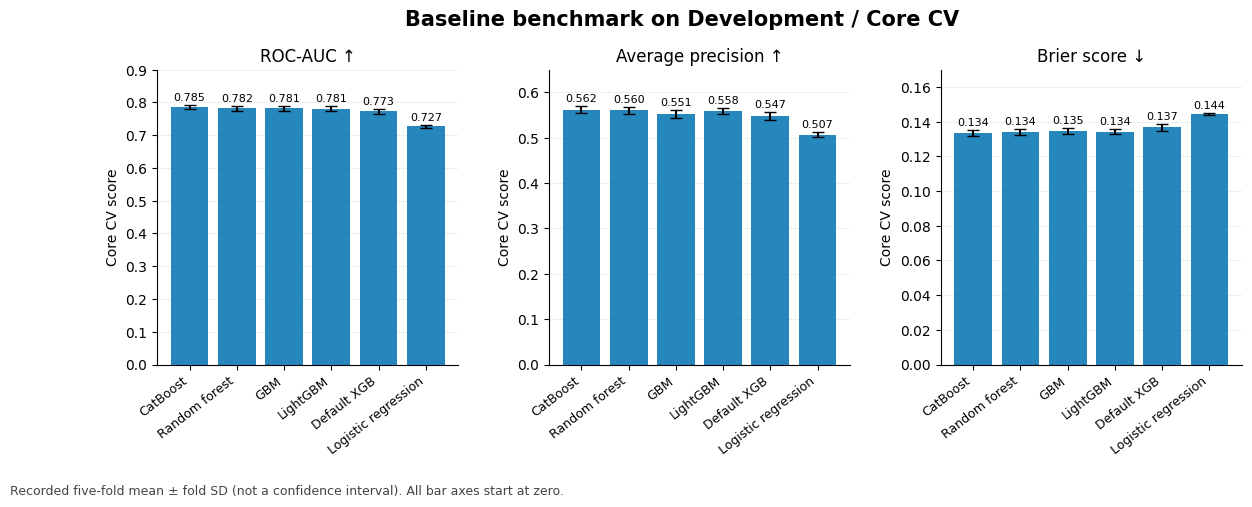

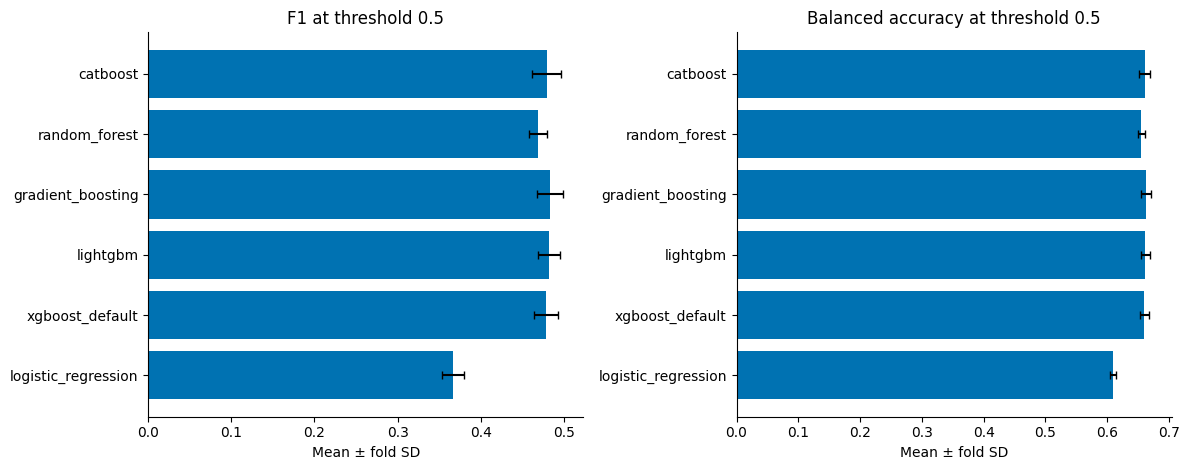

In [4]:
show_figure(viz.plot_baseline_benchmark(baseline))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, metric, title in zip(axes, ['f1', 'balanced_accuracy'], ['F1 at threshold 0.5', 'Balanced accuracy at threshold 0.5']):
    ax.barh(ranking['model'], ranking[f'{metric}_mean'], xerr=ranking[f'{metric}_std'],
            color='#0072B2', capsize=3)
    ax.invert_yaxis()
    ax.set_xlabel('Mean ± fold SD')
    ax.set_title(title)
fig.tight_layout()
show_figure(fig)


## 4. Đường cong ROC và PR: giới hạn của artifact

ROC cần `(y_true, y_score)` để tính TPR/FPR qua mọi ngưỡng; PR cũng cần cùng điểm xác suất. Artifact hiện tại chỉ có các chỉ số tổng hợp của sáu mô hình, không có các xác suất out-of-fold theo fold. Vì vậy phần thực hành này **ghi nhận thiếu dữ liệu**, không dựng đường cong giả và không chạy lại benchmark.

Nếu bổ sung ghi dự đoán cho một thực nghiệm Development được phê duyệt sau này, cần giữ `model`, `fold`, chỉ số dòng Core, `y_true`, `y_score`; dự đoán phải đến từ mô hình chưa thấy dòng đó. Với Final Test đã chấm, chỉ dùng xác suất đã lưu từ lần chấm duy nhất; không chấm lại để bổ sung hình.


In [5]:
prediction_files = [p for p in (project_root / 'artifacts' / 'predictions').glob('*')
                    if p.is_file() and p.name != '.gitkeep']
display(pd.DataFrame([{'evidence': 'OOF scores of all six baseline models',
                       'available_in_current_artifacts': False,
                       'reason': 'baseline_benchmark.csv contains aggregate metrics only'},
                      {'evidence': 'Files in artifacts/predictions',
                       'available_in_current_artifacts': bool(prediction_files),
                       'reason': ', '.join(p.name for p in prediction_files) or 'No saved prediction scores'}]))


,evidence,available_in_current_artifacts,reason
0,OOF scores of all six baseline models,False,baseline_benchmark.csv contains aggregate metr...
1,Files in artifacts/predictions,False,No saved prediction scores


## 5. Chi phí thực nghiệm và khả năng áp dụng

`duration_sec` là thời gian **toàn bộ phép đánh giá CV** đo bằng đồng hồ thực trong script, gồm xây dựng pipeline, fit và tính chỉ số; không phải thời gian fit trung bình của một mô hình triển khai. Kết quả phụ thuộc phần cứng, số luồng và cấu hình thư viện. Chưa đo latency online hoặc bộ nhớ.

Trong nghiệp vụ tín dụng, AUC/AP hỗ trợ phân biệt rủi ro; precision/recall tại 0,5 cho thấy hậu quả của quy tắc quyết định đang dùng. Chọn ngưỡng theo chi phí bỏ sót nợ xấu và từ chối nhầm phải diễn ra trên Development, trước lần đánh giá độc lập tiếp theo.


,model,duration_sec,roc_auc_mean,average_precision_mean,mean_cv_time_per_fold_sec_approx
0,catboost,4.937427,0.784666,0.561650,0.987485
1,random_forest,3.983848,0.782083,0.559917,0.796770
2,gradient_boosting,52.370324,0.781476,0.551224,10.474065
3,lightgbm,6.182107,0.780781,0.558117,1.236421
4,xgboost_default,4.787230,0.772620,0.546795,0.957446
5,logistic_regression,2.934319,0.726933,0.506727,0.586864


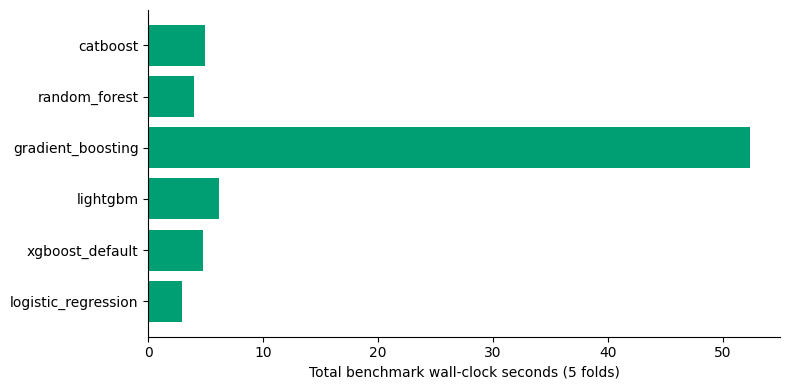

In [6]:
costs = ranking[['model', 'duration_sec', 'roc_auc_mean', 'average_precision_mean']].copy()
costs['mean_cv_time_per_fold_sec_approx'] = costs['duration_sec'] / 5
display(costs)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(costs['model'], costs['duration_sec'], color='#009E73')
ax.set_xlabel('Total benchmark wall-clock seconds (5 folds)')
ax.invert_yaxis()
fig.tight_layout()
show_figure(fig)


## 6. RQ4: XGBoost tối ưu đứng ở đâu so với baseline?

Đọc thêm các điểm Development đã khóa, không dùng Final Test để chọn mô hình. Cần phân biệt benchmark cấu hình đối chứng với HPO: chỉ XGBoost được dành ngân sách 64 trial mỗi nhánh, nên chưa đủ để kết luận XGBoost tốt hơn mọi thuật toán nếu tất cả đều được tối ưu tương đương.


In [7]:
tpe = read_table('xgb_single_hpo_best.csv', ['roc_auc_cv']).iloc[0]
selected = read_table('xgb_pareto_selected.csv', ['selection_role', 'roc_auc_cv'])
best_baseline = ranking.iloc[0]
display(Markdown(f"**Kết quả RQ4:** baseline dẫn đầu là **{best_baseline['model']}** "
                 f"(AUC {best_baseline['roc_auc_mean']:.6f}). TPE đạt **{tpe['roc_auc_cv']:.6f}**, "
                 f"cao hơn {tpe['roc_auc_cv'] - best_baseline['roc_auc_mean']:.6f}. "
                 f"NSGA-II ưu tiên AUC đạt **{selected.set_index('selection_role').loc['auc', 'roc_auc_cv']:.6f}**. "
                 "Đây là xếp hạng trên Core CV của các cấu hình đã chạy, chưa phải bằng chứng vượt trội có ý nghĩa thống kê hoặc cho dữ liệu khác."))


**Kết quả RQ4:** baseline dẫn đầu là **catboost** (AUC 0.784666). TPE đạt **0.787436**, cao hơn 0.002770. NSGA-II ưu tiên AUC đạt **0.787721**. Đây là xếp hạng trên Core CV của các cấu hình đã chạy, chưa phải bằng chứng vượt trội có ý nghĩa thống kê hoặc cho dữ liệu khác.

### Tự kiểm tra trước Notebook 05

1. Vì sao một mô hình có AUC cao vẫn có recall thấp ở ngưỡng 0,5?
2. Vì sao không thể suy ra ROC/PR từ `roc_auc_mean` và `average_precision_mean`?
3. Cần thay đổi gì trong thiết kế để so sánh công bằng các thuật toán có ngân sách HPO khác nhau?

Tiếp tục [05. HPO và Pareto](05_xgb_hpo_and_pareto_analysis.ipynb).
